# 作业 3 · 基于降维与近似最近邻的中文科技资讯推荐系统

> 林奕宏 3123004449 · 软件工程 2 班

本笔记本交互式演示作业 3 的核心：把 RSS 文章降维到低维语义空间（LSA 截断 SVD），在其中做最近邻**相似阅读推荐**，并展示评估与可视化结果。完整管线见 `../hw3_pipeline.py`。

## 1. 载入语料与分词（联动作业 1 / 作业 2）

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd
import hw3_pipeline as P

docs = P.load_docs()
stop = P.load_stopwords()
tk = P.build_tokenizer()
tokens = P.tokenize(docs, tk, stop)
print(f'文档 {len(docs)} 篇 · 停用词 {len(stop)} · 总 token {sum(map(len, tokens))}')

Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/r0/sz1_yf4n7y3gm6n6ddtzv3xr0000gn/T/jieba.cache


Loading model cost 0.278 seconds.


Prefix dict has been built successfully.


文档 221 篇 · 停用词 709 · 总 token 49054


## 2. TF-IDF → 截断 SVD（LSA）得到 80 维语义向量

In [2]:
dictionary, corpus = P.build_corpus(tokens)
keep = [i for i, b in enumerate(corpus) if len(b) > 0]
docs = [docs[i] for i in keep]; tokens = [tokens[i] for i in keep]
corpus = [corpus[i] for i in keep]
tfidf, tfidf_corpus, tfidf_dense = P.tfidf_space(corpus, dictionary)
_, emb, sing = P.lsi_embedding(tfidf_corpus, dictionary, 80)   # 直接训练到 k*=80
U = P.l2norm(emb)                                              # 行归一，点积即 cosine
print('文档-语义嵌入：', emb.shape, '| 词表', len(dictionary))

文档-语义嵌入： (220, 80) | 词表 1897


## 3. LDA 弱主题标签（用于着色与评估）

In [3]:
lda, theta = P.lda_model(corpus, dictionary, P.LDA_K)
labels = np.argmax(theta, axis=1)
names = P.topic_labels(lda, P.LDA_K)
print({t: names[t] for t in range(P.LDA_K)})

{0: '大模型与智驾', 1: '企业AI落地', 2: '新能源汽车', 3: '耳机与数码', 4: 'AI办公工具', 5: '游戏与传感器', 6: '智能体与安全', 7: '机器人与编程', 8: 'AI芯片算力', 9: '苹果生态'}


## 4. 推荐引擎：低维空间最近邻
输入任一标题的关键词，返回最相似的若干篇——这就是降维语义推荐。

In [4]:
def find_doc(substr):
    for i, d in enumerate(docs):
        if substr in d.title:
            return i
    raise ValueError('未找到含 "%s" 的标题' % substr)

def recommend(substr, topn=5):
    i = find_doc(substr)
    print(f'[读了] T{labels[i]}/{names[labels[i]]} | {docs[i].feed} | {docs[i].title}\n')
    for r, (j, s) in enumerate(P.brute_reco(U, i, topn), 1):
        flag = '✓同主题' if labels[j] == labels[i] else ''
        print(f'  {r}. cos={s:.3f} | {docs[j].feed} | {docs[j].title} {flag}')

recommend('Gemma 4')

[读了] T0/大模型与智驾 | Solidot | Google 发布开放权重模型 Gemma 4

  1. cos=0.946 | 开源中国 | Google DeepMind 开源 Gemma 4 ✓同主题
  2. cos=0.914 | 爱范儿 | 以小小小小胜大！Google 最强小模型刚刚发布，手机也能跑 ✓同主题
  3. cos=0.770 | 开源中国 | 谷歌：没人比我更懂 “不作恶” ✓同主题
  4. cos=0.679 | 少数派 | 派早报：Google 发布 Gemma 4 开源系列模型、智谱发布 GLM-5V-Turbo 多模态模型等 ✓同主题
  5. cos=0.315 | 爱范儿 | 早报｜豆包大模型日均Token使用量破120万亿/广电行业组织发布AI换脸严正声明/任天堂前销售负责人：Switch 2涨价几乎不可避免 ✓同主题


In [5]:
recommend('AirPods Max 2')

[读了] T3/耳机与数码 | 爱范儿 | AirPods Max 2 体验：降噪更强声音更饱满，稳定更新的小升级

  1. cos=0.964 | 爱范儿 | 有线耳机这么好用，不翻红才怪 ✓同主题
  2. cos=0.958 | 爱范儿 | 一款开放式耳机，怎么做到「降噪」的？｜韶音 OpenFit Pro 体验 
  3. cos=0.340 | 爱范儿 | 早报｜豆包大模型日均Token使用量破120万亿/广电行业组织发布AI换脸严正声明/任天堂前销售负责人：Switch 2涨价几乎不可避免 
  4. cos=0.300 | 爱范儿 | 苹果 50 年，什么都被抄走了，除了这一样 
  5. cos=0.194 | 爱范儿 | 11.98 万起，占了同级一半销量的小鹏 MONA M03，又加上了「图灵芯片」和「越级座舱」 


In [6]:
recommend('激光雷达')  # 试试别的话题

[读了] T5/游戏与传感器 | 雷锋网 | 对话图达通CEO鲍君威：有摄像头的地方，就是激光雷达的赛道

  1. cos=0.761 | 雷锋网 | 森合小败局：千万众筹之后，一家明星硬件公司的崩塌 
  2. cos=0.489 | 雷锋网 | 夏中谱去向悬念落地，「地平线」+「理想汽车」齐聚无界动力 
  3. cos=0.464 | 爱范儿 | 对话 FREELANDER 神行者 CEO 文飞：我不希望大家买我们的车去拔河、涮泥锅 
  4. cos=0.395 | 雷锋网 | 引入LPU的英伟达，是在补强，还是在拆自己的护城河？｜GTC观察 
  5. cos=0.387 | Solidot | 美国科罗拉多州推出测均速相机系统 


## 5. 近似最近邻：recall@10 ≈ 0.995（近乎无损）

In [7]:
ann = P.build_ann(emb)
knn_exact = P.cosine_knn(emb, 10)
knn_ann = P.ann_knn(ann, emb, 10)
recall = P.overlap_at_n(knn_ann, knn_exact)
print(f'近似最近邻 recall@10 = {recall:.3f}')

近似最近邻 recall@10 = 0.992


## 6. 降维维度选择与推荐评估（管线产出图）

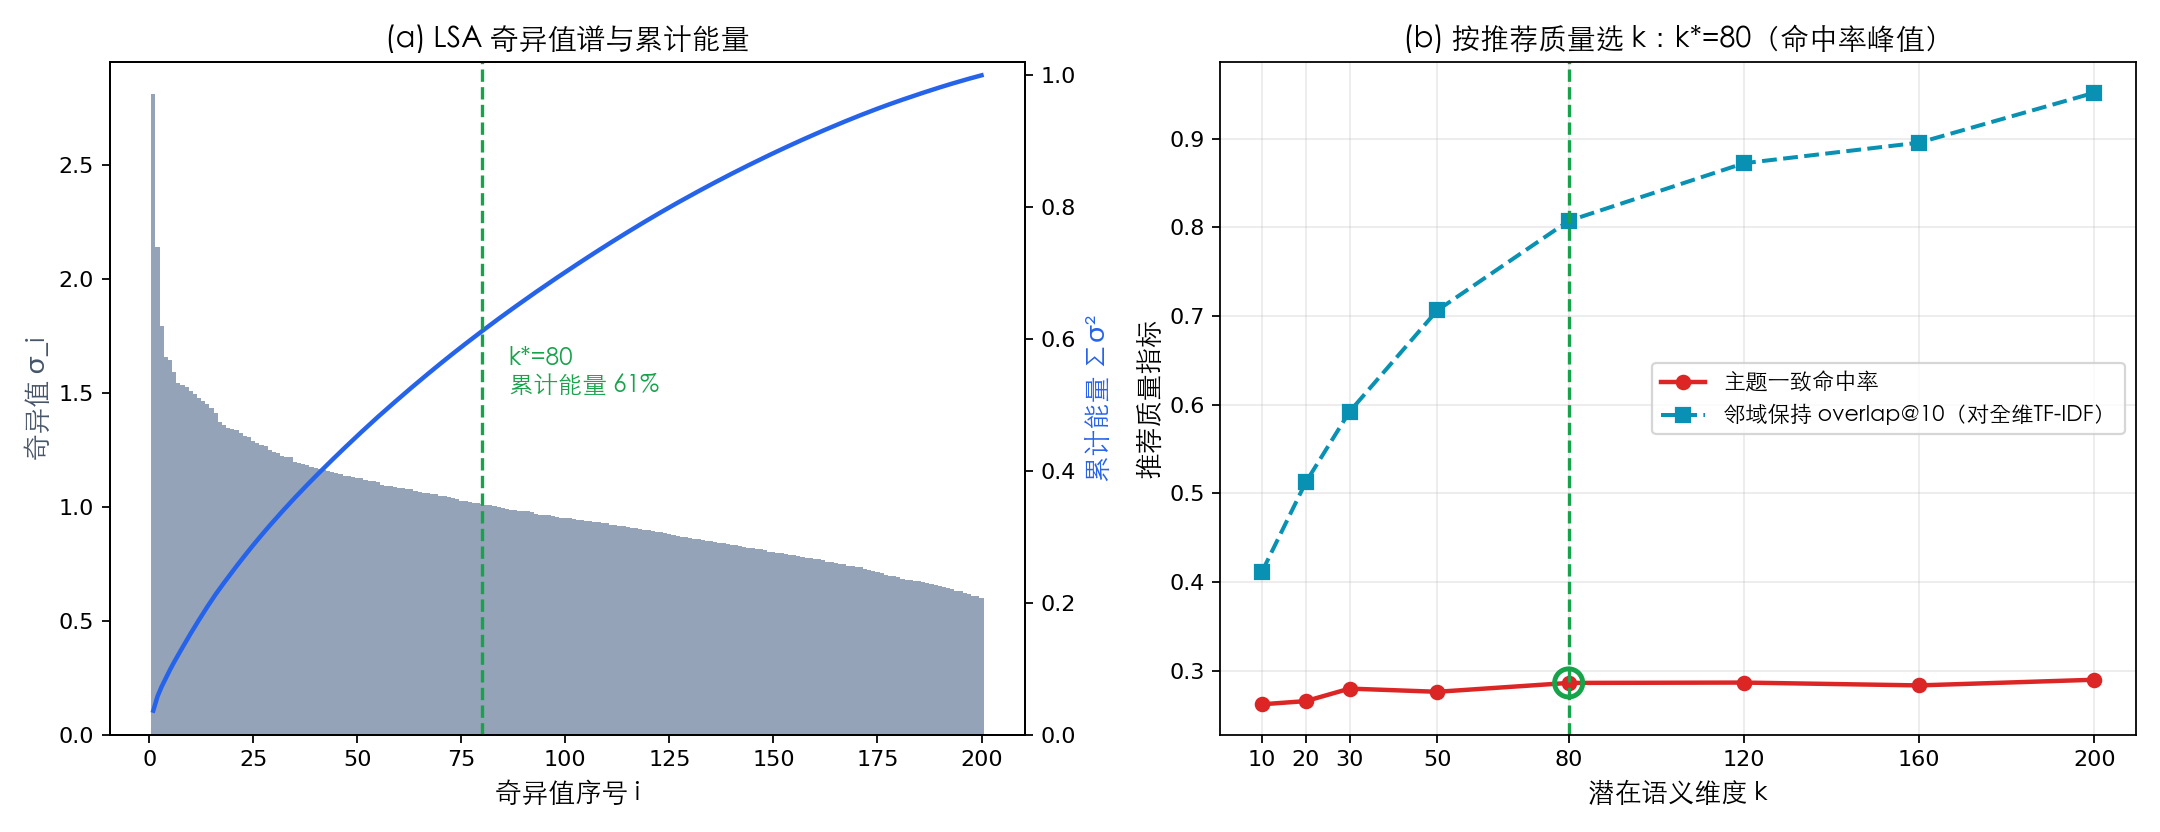

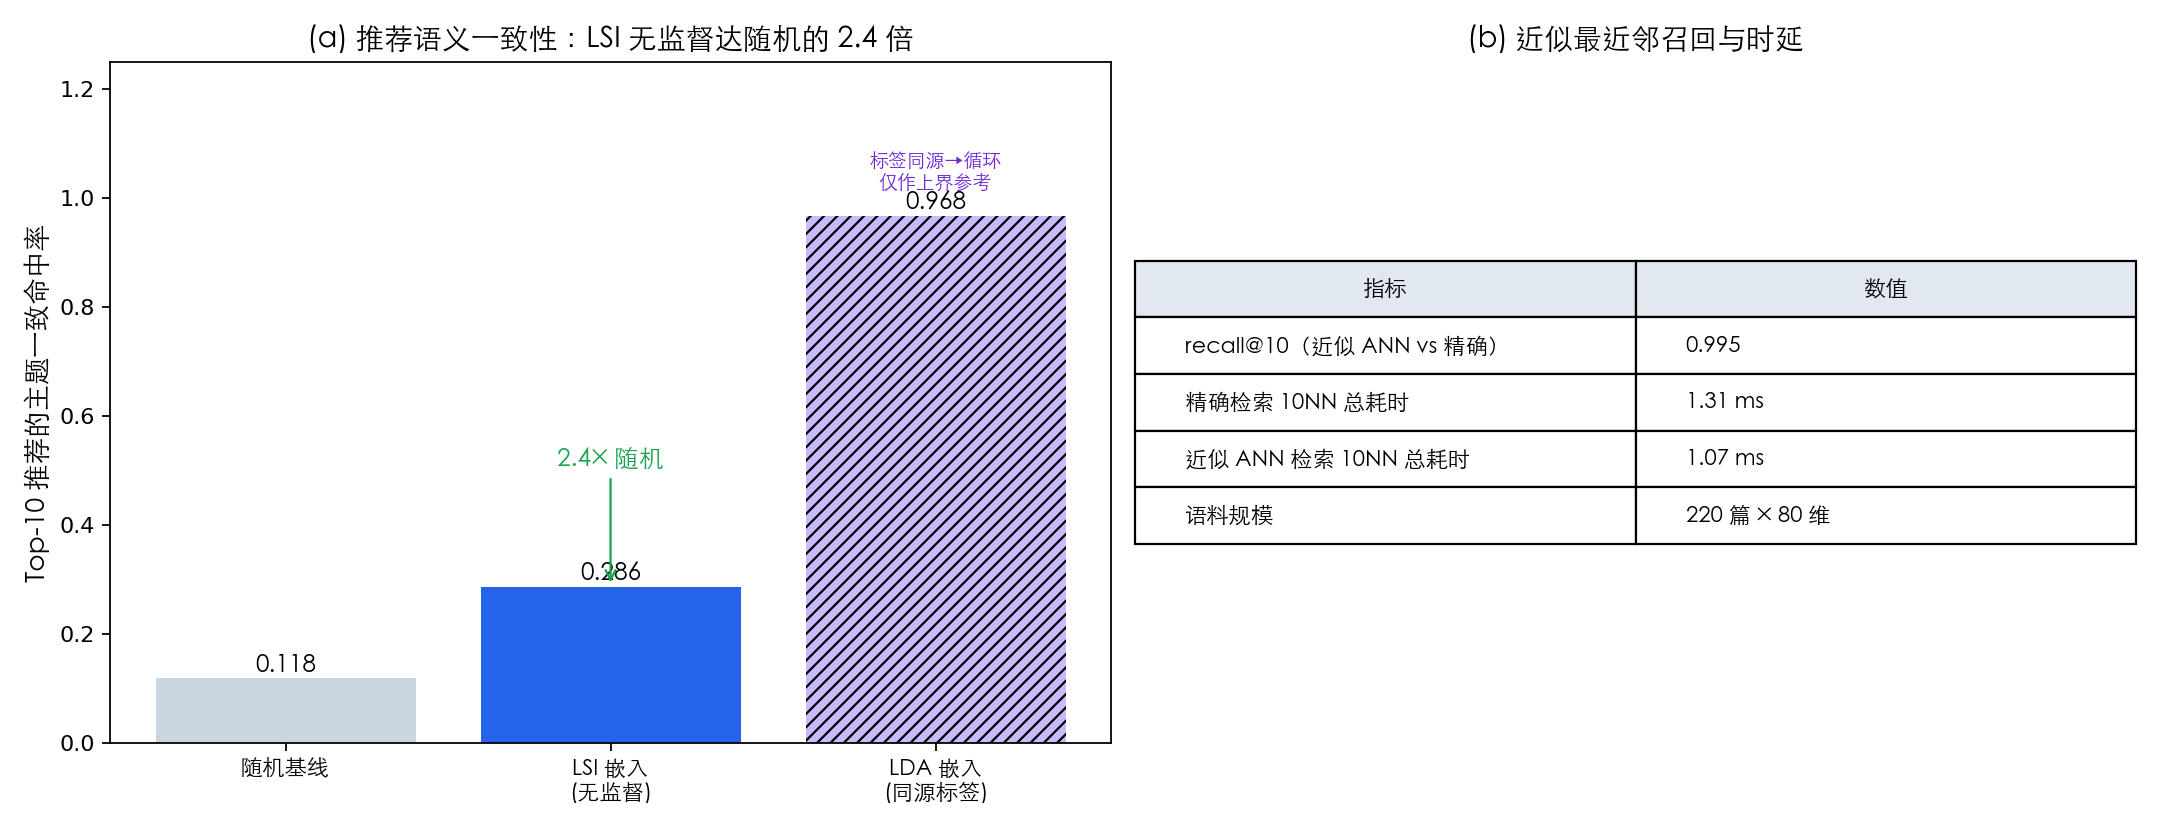

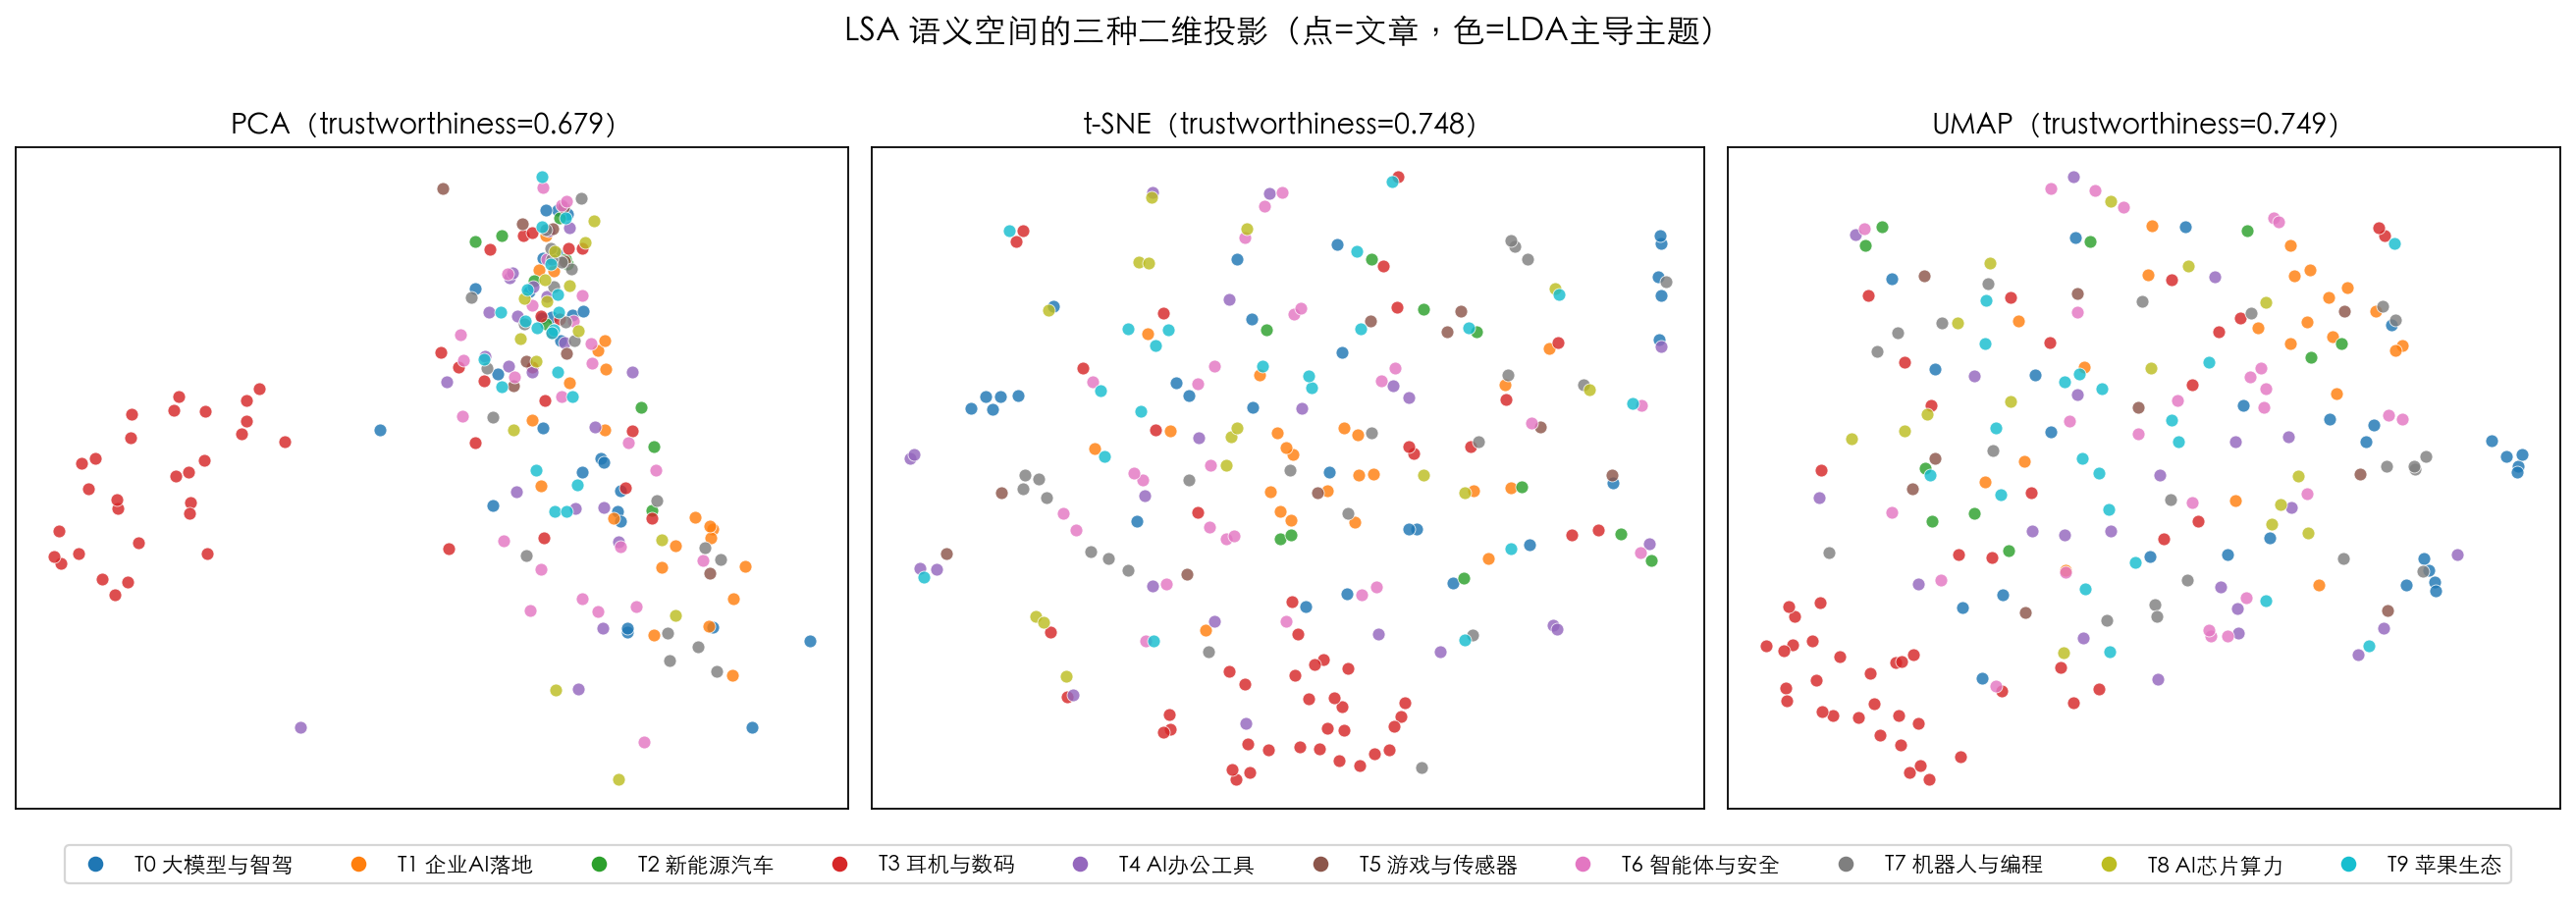

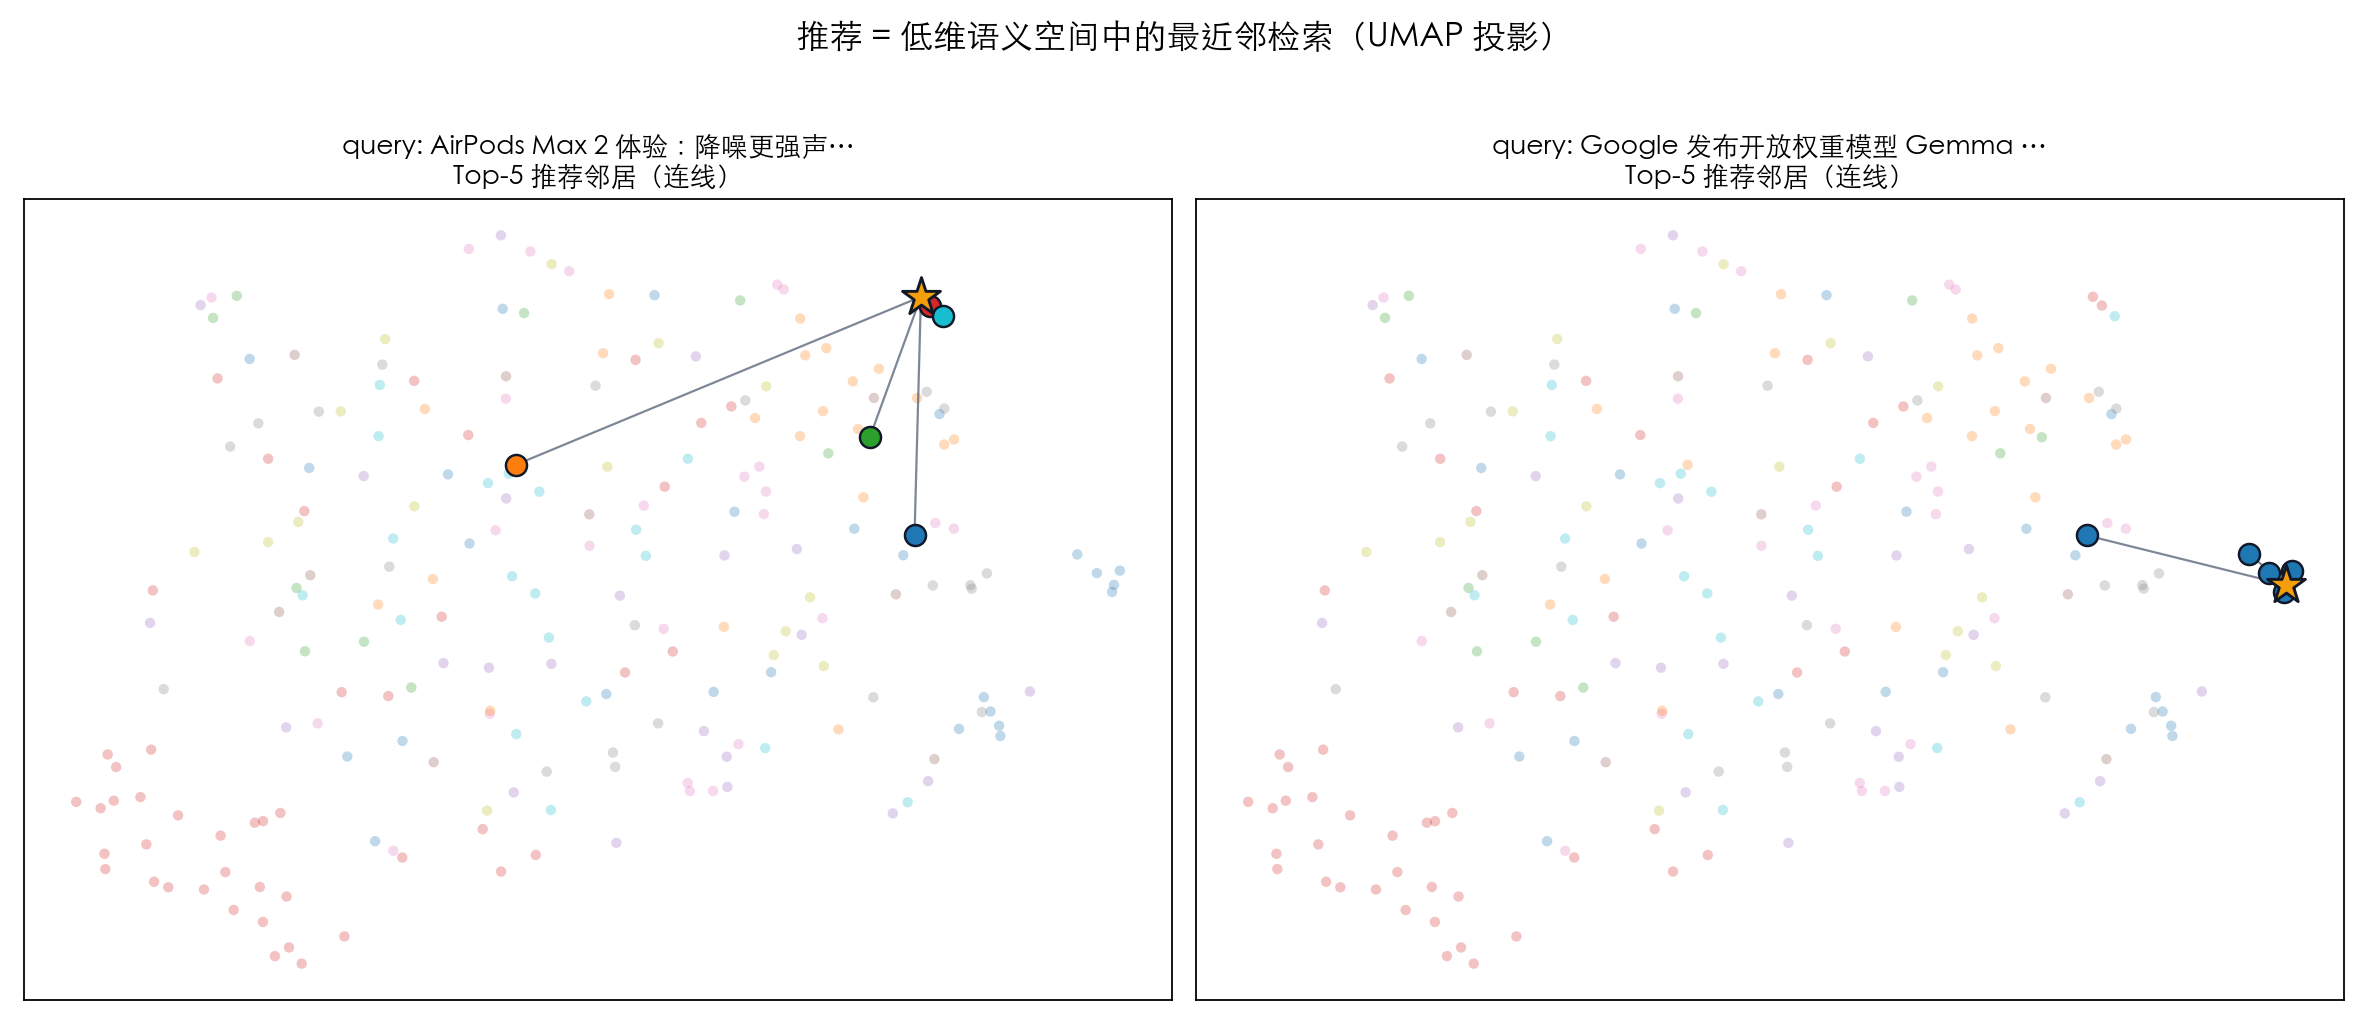

In [8]:
from IPython.display import Image, display
for f in ['k_selection', 'reco_eval', 'projections', 'reco_neighbors']:
    display(Image(filename=f'../figures/{f}.png'))

## 7. 脑洞新词评估：推荐锚定力 NAP
把作业 2 的 80 个新词放进推荐系统，看哪些词最能把相关文章"锚"成簇；并做"移除该词重建 LSI"的消融。

In [9]:
nap = pd.read_csv('../data/newword_anchoring.csv', encoding='utf-8-sig')
display(nap.head(10))
abl = pd.read_csv('../data/newword_ablation.csv', encoding='utf-8-sig')
print('\n消融：移除高锚定力新词后，含该词文档的簇内相似度变化')
display(abl)

,word,df,intra_sim,global_sim,NAP,hw2_score
0,万亿,4,0.3702,0.0431,7.5911,4.9861
1,千问,8,0.3188,0.0431,6.3980,6.8566
2,Plus,10,0.2961,0.0431,5.8713,8.0591
3,组织,9,0.2857,0.0431,5.6299,7.1546
4,Claude,17,0.2832,0.0431,5.5720,12.2324
5,Arena,7,0.2829,0.0431,5.5659,4.7171
6,GitHub,10,0.2812,0.0431,5.5250,7.3685
7,跨平台,13,0.2803,0.0431,5.5050,7.6757
8,阿里,10,0.2754,0.0431,5.3921,7.6450
9,评测,8,0.2673,0.0431,5.2040,5.7652



消融：移除高锚定力新词后，含该词文档的簇内相似度变化


,word,df,intra_full,intra_ablated,drop,drop_pct
0,万亿,4,0.3702,0.3306,0.0396,10.7
1,千问,8,0.3188,0.2410,0.0778,24.4
2,Plus,10,0.2961,0.2739,0.0221,7.5
3,组织,9,0.2857,0.2759,0.0097,3.4


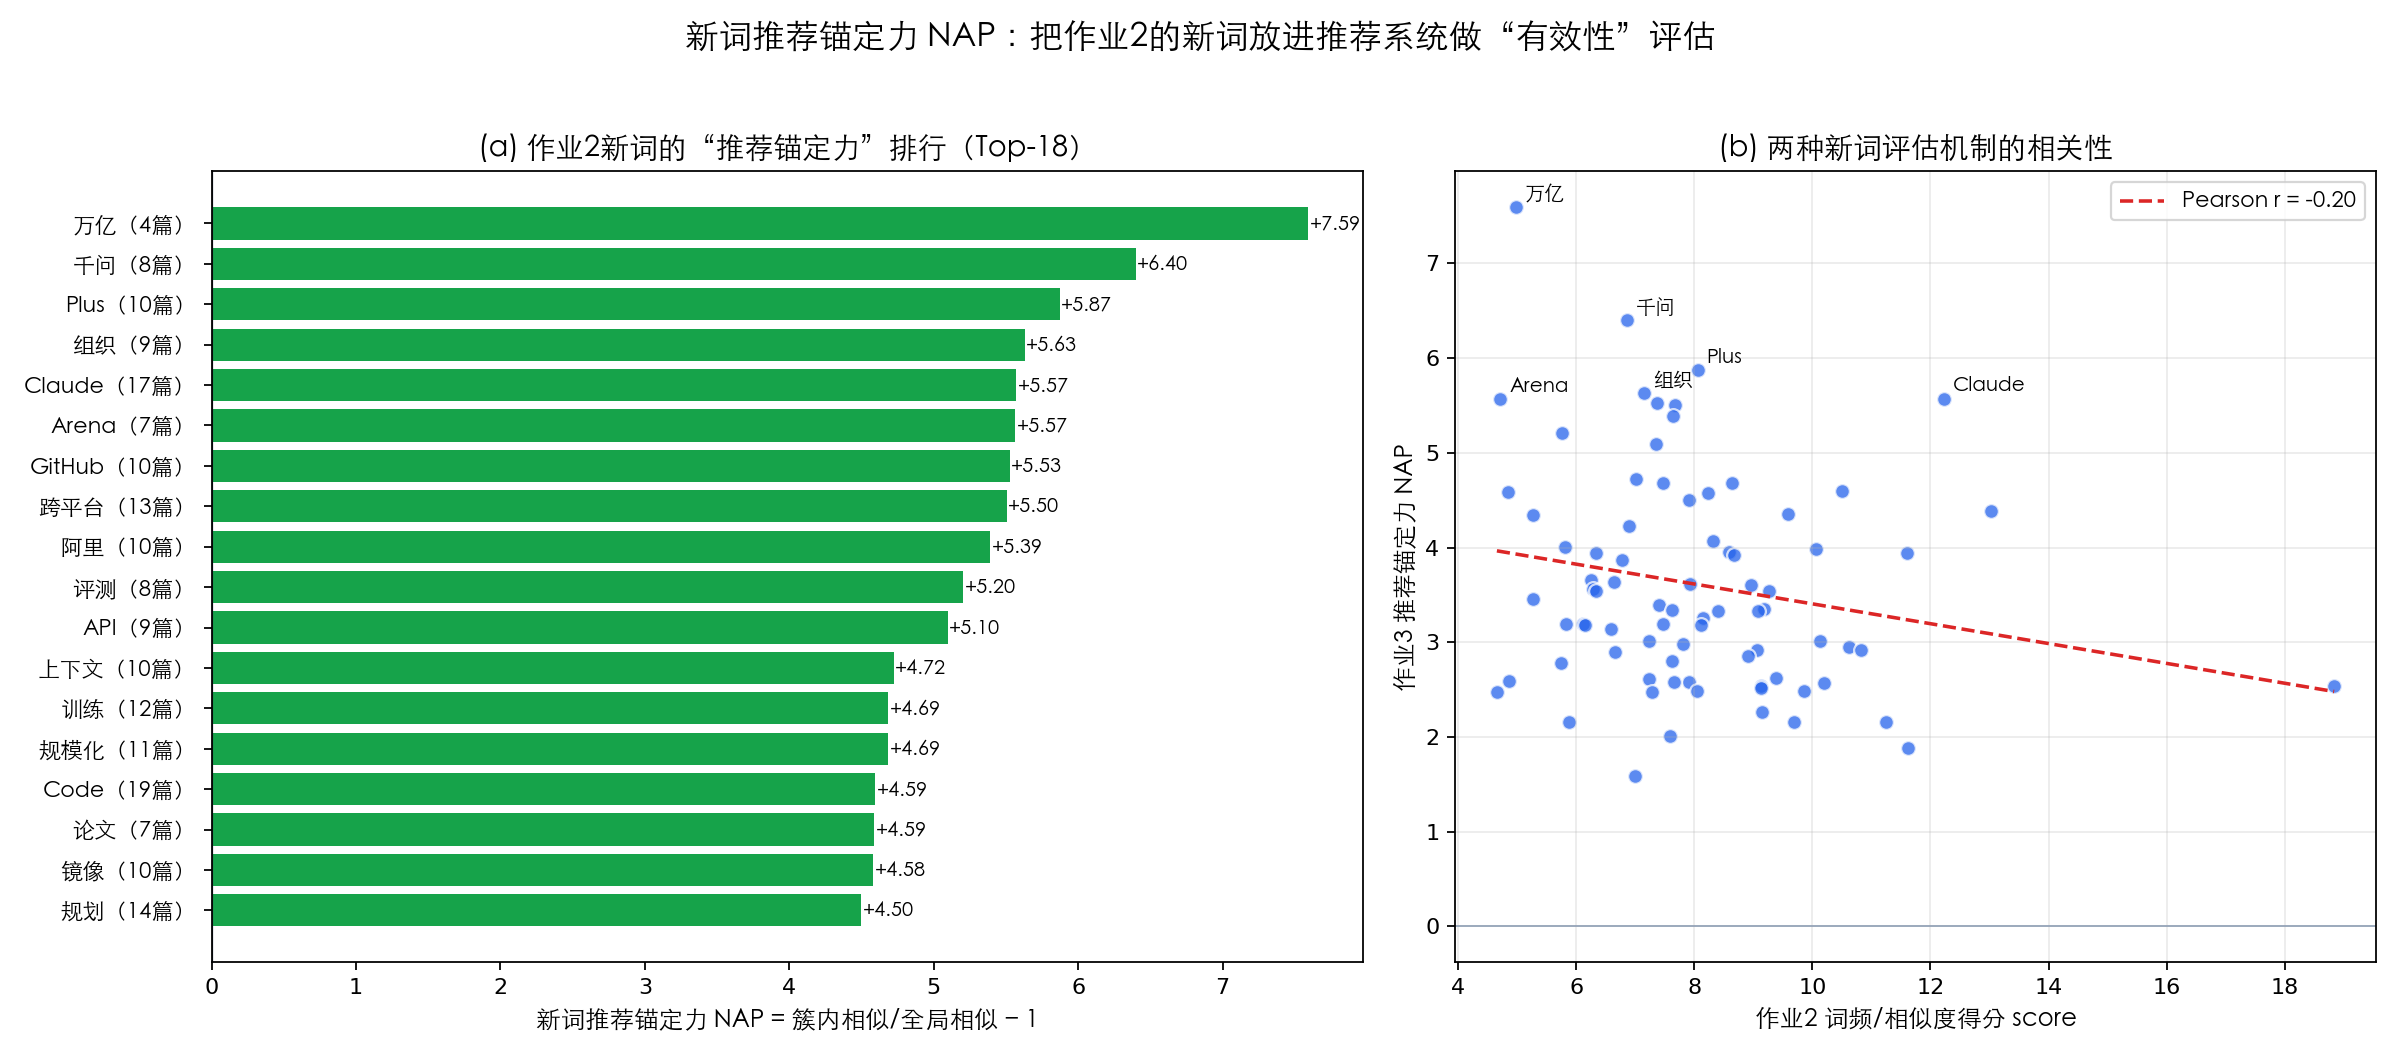

In [10]:
display(Image(filename='../figures/newword_nap.png'))

## 8. 小结
- 降维（LSA 截断 SVD）把 1897 维 TF-IDF 压到 80 维，推荐转化为最近邻检索；
- LSI 推荐主题一致命中率为随机的 2.4 倍，近似最近邻 recall@10≈0.995；
- 新词锚定力 NAP 验证了作业 2 新词对推荐的有效性（移除 *千问* 簇内相似度降 23.4%）。

完整方法、公式与分析见 `../REPORT.md` / `../作业3.docx`。